In [ ]:
from joblib import Parallel, delayed
import os
os.environ['R_HOME'] = '/datapool/home/zhijian/zhijian/miniconda3/envs/soybean_sam/lib/R'
# os.environ['R_HOME'] = '/public/home/liuzj/softwares/anaconda3/envs/hormone/lib/R'
import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
import rpy2.ipython.html
rpy2.ipython.html.init_printing()
from jpy_tools.rTools import py2r, r2py, r_inline_plot, rHelp, trl, rSet, rGet, ad2so, so2ad, so2md, rcontext, Trl, r2py_re, py2r_re, RR, FR
from jpy_tools import loadPkl, toPkl
rBase = importr('base')
rUtils = importr('utils')
dplyr = importr('dplyr')
reticulate = importr('reticulate')
R = ro.r
T = Trl()
R("options(browser='firefox', shiny.port=6533, max.print=200)")
%load_ext rpy2.ipython


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

<Figure size 100x100 with 0 Axes>

In [ ]:
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
import scipy.sparse as ss
from tqdm import tqdm
from loguru import logger
from functools import partial
from jpy_tools import singleCellTools

In [ ]:
%config InlineBackend.figure_format = 'retina'
import seaborn as sns
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.font_manager as font_manager
import marsilea as ma
import marsilea.plotter as mp
# plt.rcParams['figure.dpi'] = 150
font_dirs = ["/datapool/home/zhijian/.local/share/mpl_fontkit/"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
plt.rcParams["font.family"] = "Arial"
sns.despine(top=True, right=True)
from itertools import product
from functools import reduce
import patchworklib as pw
from jpy_tools.otherTools import pwRecoverSeaborn, pwStack, F, pwShow
pw.show = pwShow
fc_recoverSns = pwRecoverSeaborn()
import seaborn.objects as so
from cycler import cycler
dt_snsStyle = {**sns.axes_style('ticks'), "legend.frameon": False, "axes.spines.top":False, "axes.spines.right":False, "axes.prop_cycle":cycler(color=['grey'])}
so.Plot.config.theme.update(dt_snsStyle)
from jpy_tools.soExt import Axhline, Axvline, mvLegToAx
from jpy_tools import soExt
plt.set_loglevel('Warning')

<Figure size 640x480 with 0 Axes>

In [ ]:
from functools import partial

In [ ]:
dir_result = '/datapool/home/zhijian/projects/hormone/analysis/'

In [ ]:
def reloadPackages(package):
    import importlib
    from types import ModuleType
    for p in dir(package):
        p = getattr(package, p)
        if isinstance(p, ModuleType):
            importlib.reload(p)
    importlib.reload(package)


In [ ]:
ead = singleCellTools.EnhancedAnndata(loadPkl('ad_apr_embedding_0523_sct', lambda **dt:sc.read_h5ad(**dt), arg_path='filename', dir_path=dir_result))

2025-05-20 16:48:56.531 | WARNING  | jpy_tools.singleCellTools:rawLayer:608 - rawLayer will be overwritten by raw and all the related objects will be re-initialized


# BULK JA SA ABA data

In [ ]:
df_bulkMtx = pd.read_csv(
    "/datapool/data/Users/zhijian/projects/hormone/bulk_sa_ja_aba_data/analyzeNGSData/snakemake/results/step5_extractGeneCounts/allSampleGeneCounts.csv"
)
df_bulkMtx = df_bulkMtx.query("gene_id.str.startswith('AT')", engine='python')
df_bulkMtx.set_index('gene_id', inplace=True)
df_bulkMtx = df_bulkMtx.astype(int)

In [ ]:
ad_bulk = sc.AnnData(df_bulkMtx.T)

In [ ]:
ad_bulk.layers['raw'] = ad_bulk.X.copy()
ad_bulk.layers['cpm'] = ad_bulk.X.copy()

In [ ]:
ad_bulk.obs['Hormone'] = ad_bulk.obs.index.str.split('_').str[:-2].str.join('_')
ad_bulk.obs['Time'] = ad_bulk.obs.index.str.split('_').str[-2]
ad_bulk.obs['Replicate'] = ad_bulk.obs.index.str.split('_').str[-1]
sc.pp.normalize_total(ad_bulk, target_sum=1000000, layer='cpm')
ad_bulk.obs['Total'] = ad_bulk.layers['raw'].sum(axis=1)
sc.pp.log1p(ad_bulk, layer='cpm')

In [ ]:
ad_bulk[:, 'AT1G08810'].to_df('cpm').join(ad_bulk.obs[['Hormone', 'Time']]).groupby(['Hormone', 'Time']).mean().unstack().T

Hormone              ABA      DMSO        JA    JA_ABA     JA_SA        SA  \
          Time                                                               
AT1G08810 05h   1.809512  2.025475  1.875316  1.587287  2.195498  2.257364   
          3h    1.599115  2.367700  2.080819  1.635003  2.171261  2.280133   

Hormone           SA_ABA     S_A_J  
          Time                      
AT1G08810 05h   1.962968  2.026418  
          3h    1.744907  1.679640

## 0.5 hpt

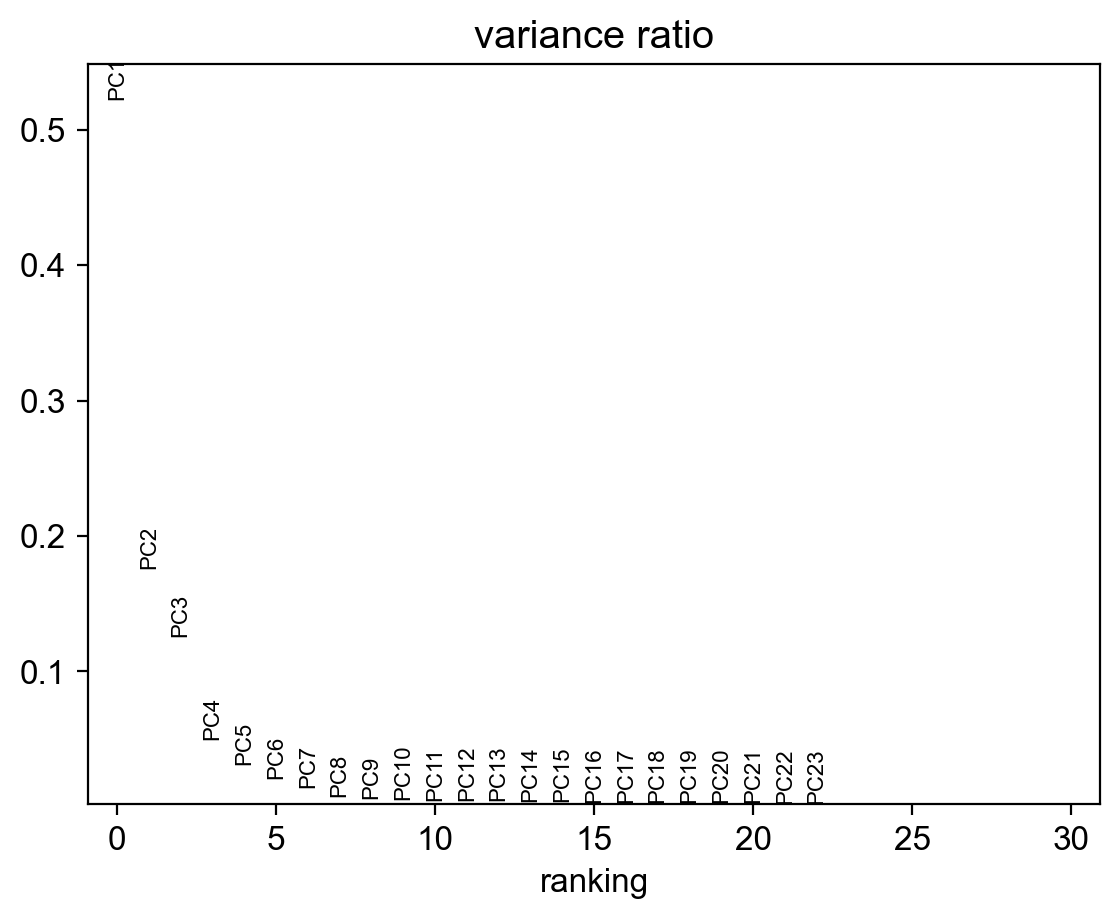

In [ ]:
ad_bulk5 = ad_bulk[ad_bulk.obs['Time'] == '05h']
sc.pp.highly_variable_genes(ad_bulk5, layer='cpm', n_top_genes=5000, flavor='seurat_v3')
sc.tl.pca(ad_bulk5, layer='cpm')
sc.pl.pca_variance_ratio(ad_bulk5)

In [ ]:
ad_bulk5.obs["Treatment"] = (
    ad_bulk5.obs["Hormone"]
    .astype("category")
    .cat.set_categories(
        [
            "ABA",
            "JA",
            "SA",
            "JA_ABA",
            "SA_ABA",
            "JA_SA",
            "S_A_J",
            "DMSO"
        ]
    )
)
ad_bulk5.obs["Treatment"] = ad_bulk5.obs["Treatment"].map(
    lambda x: {
        "JA_ABA": "ABA+JA",
        "SA_ABA": "ABA+SA",
        "JA_SA": "JA+SA",
        "S_A_J": "ABA+JA+SA",
        "DMSO":'Mock'
    }.get(x, x)
)

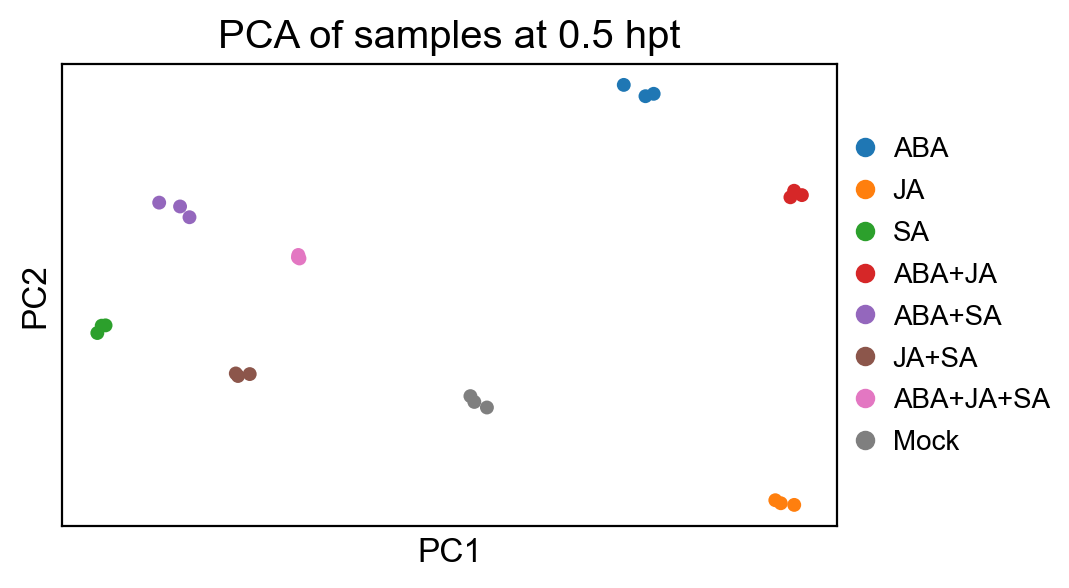

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
sc.pl.pca(ad_bulk5, color='Treatment', size=100, title='PCA of samples at 0.5 hpt', ax=ax)

In [ ]:
import anndata
import scipy.sparse as sp
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri, default_converter
from rpy2.robjects.conversion import localconverter
from tqdm.auto import tqdm  # 导入进度条神器，支持终端和 Jupyter

# ==========================================
# 1. 从 AnnData 提取数据
# ==========================================
# ad_bulk5 = anndata.read_h5ad("your_data.h5ad")
layer_key = 'raw' 

if sp.issparse(ad_bulk5.layers[layer_key]):
    counts_matrix = ad_bulk5.layers[layer_key].T.toarray()
else:
    counts_matrix = ad_bulk5.layers[layer_key].T

genes = ad_bulk5.var_names.tolist()
samples = ad_bulk5.obs_names.tolist()
hormone_group = ad_bulk5.obs['Hormone'].astype(str).tolist()

# ==========================================
# 2. 显式转换并推送至 R 运行环境
# ==========================================
ro.globalenv['hormone_group'] = ro.StrVector(hormone_group)
ro.globalenv['genes'] = ro.StrVector(genes)
ro.globalenv['samples'] = ro.StrVector(samples)

with localconverter(default_converter + numpy2ri.converter):
    ro.globalenv['counts_matrix'] = ro.conversion.py2rpy(counts_matrix)

# ==========================================
# 3. 执行 R 脚本：仅进行数据构建和模型拟合 (不循环)
# ==========================================
print("正在 R 中构建模型并估计离散度 (Dispersion)...")
r_setup_script = """
suppressMessages(library(edgeR))

counts <- as.matrix(counts_matrix)
rownames(counts) <- genes
colnames(counts) <- samples

group <- factor(hormone_group)
group <- relevel(group, ref="DMSO")

y <- DGEList(counts=counts, group=group)
keep <- filterByExpr(y)
y <- y[keep, , keep.lib.sizes=FALSE]
y <- calcNormFactors(y)

design <- model.matrix(~group)
y <- estimateDisp(y, design)
fit <- glmFit(y, design)

# 将 design 矩阵的列数和列名存为变量，方便 Python 抓取
num_cols <- ncol(design)
col_names <- colnames(design)
"""
ro.r(r_setup_script)

# ==========================================
# 4. 在 Python 中循环并添加进度条！
# ==========================================
# 从 R 环境中获取列数和列名
num_cols = int(ro.r('num_cols')[0])
col_names = list(ro.r('col_names'))

deg_results = {}

# Python 的 range(2, num_cols + 1) 对应 R 的 2:ncol
# 使用 tqdm 包装 range 来生成进度条
for i in tqdm(range(2, num_cols + 1), desc="计算各处理组 DEG", unit="组"):
    
    # 获取 R 里的列名 (注意 Python 是 0 索引，所以是 i-1)
    coef_name = col_names[i - 1] 
    clean_name = coef_name.replace("group", "") # 清理前缀
    
    # 动态构建执行当前 coef 的 R 语句
    ro.globalenv['current_coef'] = i
    r_lrt_script = """
    lrt <- glmLRT(fit, coef=current_coef)
    topTags(lrt, n=Inf)$table
    """
    
    # 执行检验并获取结果 DataFrame (R 格式)
    res_r = ro.r(r_lrt_script)
    
    # 显式转换回 Pandas
    with localconverter(default_converter + pandas2ri.converter):
        deg_results[clean_name] = ro.conversion.rpy2py(res_r)

# ==========================================
# 5. 完成
# ==========================================
print("\n✅ 所有处理组分析完毕！")
print(f"包含的对比组有: {list(deg_results.keys())}")

df_deg05 = []
for contrast, df in deg_results.items():
    df = df.reset_index().rename(columns={'index': 'gene'})
    df['Hormone'] = contrast
    df['Time'] = '0.5 hpt'
    df_deg05.append(df)
df_deg05 = pd.concat(df_deg05, ignore_index=True)

正在 R 中构建模型并估计离散度 (Dispersion)...


(Intercept),groupABA,groupJA,groupJA_ABA,groupJA_SA,groupS_A_J,groupSA,groupSA_ABA


计算各处理组 DEG:   0%|          | 0/7 [00:00<?, ?组/s]


✅ 所有处理组分析完毕！
包含的对比组有: ['ABA', 'JA', 'JA_ABA', 'JA_SA', 'S_A_J', 'SA', 'SA_ABA']


## 3 hpt

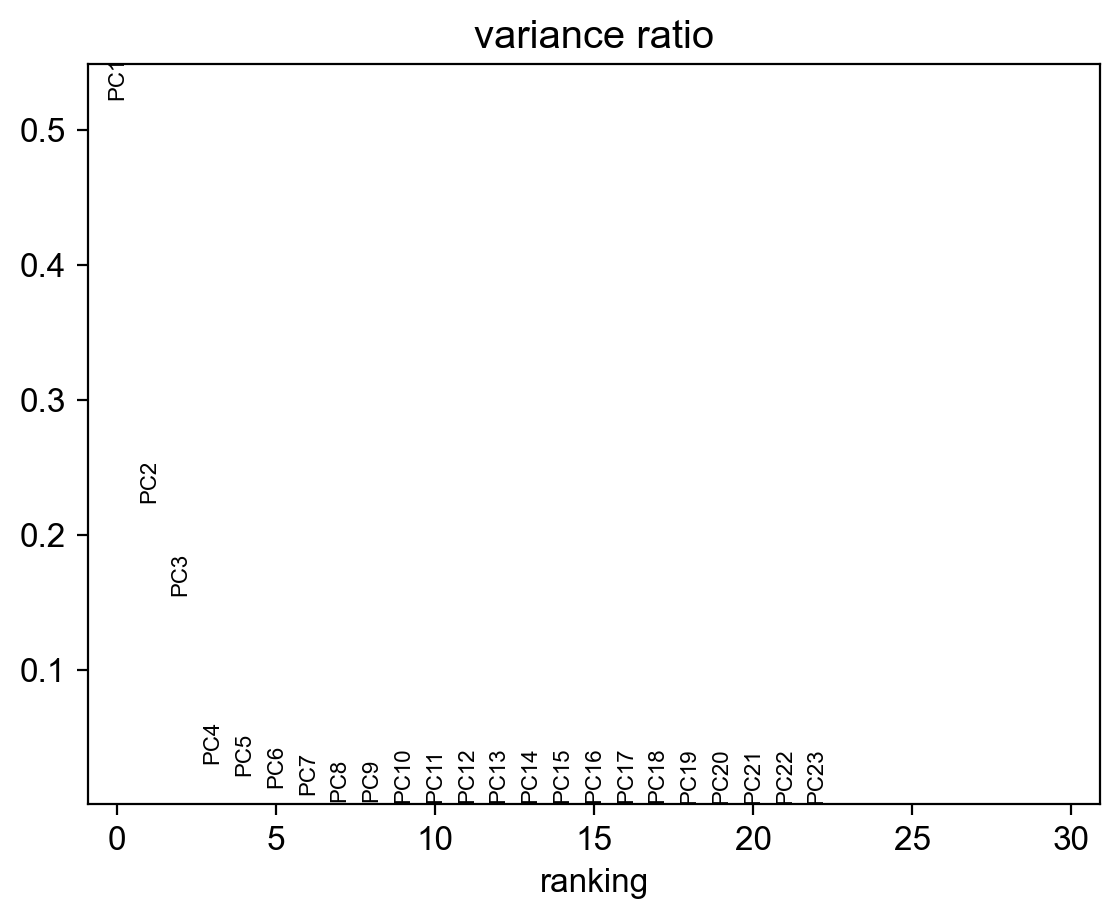

In [ ]:
ad_bulk3 = ad_bulk[ad_bulk.obs['Time'] == '3h']
sc.pp.highly_variable_genes(ad_bulk3, layer='cpm', n_top_genes=5000, flavor='seurat_v3')
sc.tl.pca(ad_bulk3, layer='cpm')
sc.pl.pca_variance_ratio(ad_bulk3)

In [ ]:
ad_bulk3.obs["Treatment"] = (
    ad_bulk3.obs["Hormone"]
    .astype("category")
    .cat.set_categories(
        [
            "ABA",
            "JA",
            "SA",
            "JA_ABA",
            "SA_ABA",
            "JA_SA",
            "S_A_J",
            "DMSO"
        ]
    )
)
ad_bulk3.obs["Treatment"] = ad_bulk3.obs["Treatment"].map(
    lambda x: {
        "JA_ABA": "ABA+JA",
        "SA_ABA": "ABA+SA",
        "JA_SA": "JA+SA",
        "S_A_J": "ABA+JA+SA",
        "DMSO":'Mock'
    }.get(x, x)
)

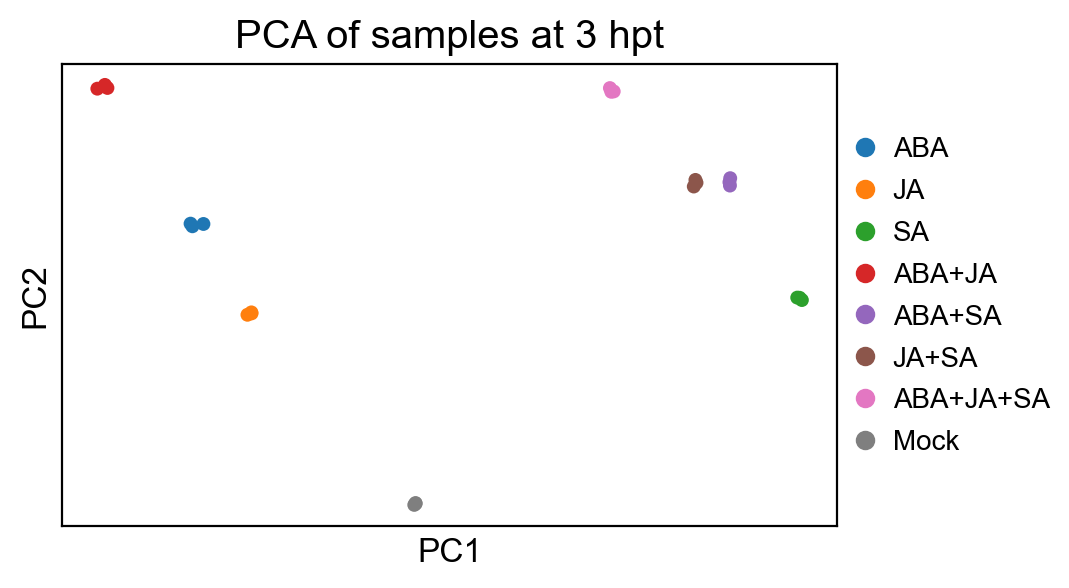

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
sc.pl.pca(ad_bulk3, color='Treatment', size=100, title='PCA of samples at 3 hpt', ax=ax)

# Interaction Analysis

In [ ]:
ad_bulk5.obs['ABA'] = ad_bulk5.obs['Hormone'].apply(lambda x: ('ABA' in x) or (x == 'S_A_J') ).astype(int)
ad_bulk5.obs['SA'] = ad_bulk5.obs['Hormone'].apply(lambda x: ('SA' in x) or (x == 'S_A_J') ).astype(int)
ad_bulk5.obs['JA'] = ad_bulk5.obs['Hormone'].apply(lambda x: ('JA' in x) or (x == 'S_A_J') ).astype(int)


In [ ]:
ad_bulk3.obs['ABA'] = ad_bulk3.obs['Hormone'].apply(lambda x: ('ABA' in x) or (x == 'S_A_J') ).astype(int)
ad_bulk3.obs['SA'] = ad_bulk3.obs['Hormone'].apply(lambda x: ('SA' in x) or (x == 'S_A_J') ).astype(int)
ad_bulk3.obs['JA'] = ad_bulk3.obs['Hormone'].apply(lambda x: ('JA' in x) or (x == 'S_A_J') ).astype(int)


In [ ]:
def normalize_treatment(series):
    """
    将包含不同格式的布尔值/数字统一转换为 R 可识别的因子 "No" 和 "Yes"
    """
    # 常见的代表“无处理”或“对照”的值
    negative_vals = {0, False, '0', 'false', 'False', 'None', 'none', 'mock', 'Mock', 'DMSO'}
    return ["No" if x in negative_vals else "Yes" for x in series]

In [ ]:
import anndata
import scipy.sparse as sp
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri, default_converter
from rpy2.robjects.conversion import localconverter
from tqdm.auto import tqdm

# ==========================================
# 0. 辅助函数：标准化因子水平
# ==========================================
def normalize_treatment(series):
    """
    将包含不同格式的布尔值/数字统一转换为 R 可识别的因子 "No" 和 "Yes"
    确保对照组基线绝对干净
    """
    negative_vals = {0, False, '0', 'false', 'False', 'None', 'none', 'mock', 'Mock', 'DMSO'}
    return ["No" if x in negative_vals else "Yes" for x in series]

# ==========================================
# 1. 从 AnnData 提取数据
# ==========================================
print("正在从 AnnData 提取与格式化数据...")
# ad_bulk5 = anndata.read_h5ad("your_data.h5ad")
layer_key = 'raw' 

if sp.issparse(ad_bulk5.layers[layer_key]):
    counts_matrix = ad_bulk5.layers[layer_key].T.toarray()
else:
    counts_matrix = ad_bulk5.layers[layer_key].T

genes = ad_bulk5.var_names.tolist()
samples = ad_bulk5.obs_names.tolist()

aba_group = normalize_treatment(ad_bulk5.obs['ABA'])
sa_group = normalize_treatment(ad_bulk5.obs['SA'])
ja_group = normalize_treatment(ad_bulk5.obs['JA'])

# ==========================================
# 2. 显式转换并推送至 R 运行环境
# ==========================================
ro.globalenv['genes'] = ro.StrVector(genes)
ro.globalenv['samples'] = ro.StrVector(samples)
ro.globalenv['aba_group'] = ro.StrVector(aba_group)
ro.globalenv['sa_group'] = ro.StrVector(sa_group)
ro.globalenv['ja_group'] = ro.StrVector(ja_group)

with localconverter(default_converter + numpy2ri.converter):
    ro.globalenv['counts_matrix'] = ro.conversion.py2rpy(counts_matrix)

# ==========================================
# 3. R 脚本：构建模型与自定义对比矩阵
# ==========================================
print("正在 R 中构建全因子交互模型并准备对比矩阵 (这步需要一些时间来估算离散度)...")
r_setup_script = """
suppressMessages(library(edgeR))

counts <- as.matrix(counts_matrix)
rownames(counts) <- genes
colnames(counts) <- samples

# 构建因子并设定 No 为基线
ABA <- factor(aba_group, levels=c("No", "Yes"))
SA <- factor(sa_group, levels=c("No", "Yes"))
JA <- factor(ja_group, levels=c("No", "Yes"))

# 初始化与过滤
y <- DGEList(counts=counts)
keep <- filterByExpr(y)
y <- y[keep, , keep.lib.sizes=FALSE]
y <- calcNormFactors(y)

# 拟合三因子全交互模型
design <- model.matrix(~ ABA * SA * JA)
y <- estimateDisp(y, design)
fit <- glmQLFit(y, design)

# ----------------------------------------
# 构建自定义对比矩阵 (用于拆解条件交互项)
# ----------------------------------------
design_cols <- colnames(design)
term_ABA_JA <- "ABAYes:JAYes"
term_ABA_SA <- "ABAYes:SAYes"
term_SA_JA  <- "SAYes:JAYes"
term_3way   <- "ABAYes:SAYes:JAYes"

con <- matrix(0, nrow=length(design_cols), ncol=3)
rownames(con) <- design_cols
colnames(con) <- c("ABA_JA_in_presence_of_SA", 
                   "ABA_SA_in_presence_of_JA", 
                   "SA_JA_in_presence_of_ABA")

# 赋值：将二重交互与三重交互相加
con[term_ABA_JA, "ABA_JA_in_presence_of_SA"] <- 1
con[term_3way, "ABA_JA_in_presence_of_SA"] <- 1

con[term_ABA_SA, "ABA_SA_in_presence_of_JA"] <- 1
con[term_3way, "ABA_SA_in_presence_of_JA"] <- 1

con[term_SA_JA, "SA_JA_in_presence_of_ABA"] <- 1
con[term_3way, "SA_JA_in_presence_of_ABA"] <- 1

# 导出变量供 Python 抓取
num_cols <- ncol(design)
col_names <- colnames(design)
num_contrasts <- ncol(con)
contrast_names <- colnames(con)
"""
ro.r(r_setup_script)

# ==========================================
# 4. 在 Python 中批量抓取计算结果
# ==========================================
col_names = list(ro.r('col_names'))
num_cols = int(ro.r('num_cols')[0])
contrast_names = list(ro.r('contrast_names'))
num_contrasts = int(ro.r('num_contrasts')[0])

deg_results = {}

# --- 阶段 1：抓取主效应与基础交互作用 (Coef) ---
for idx in tqdm(range(1, num_cols), desc="阶段 1/2: 计算主效应与基础交互项", unit="项"):
    coef_num = idx + 1 # R 语言索引从 1 开始
    raw_name = col_names[idx]
    
    # 智能命名逻辑
    if ":" in raw_name:
        clean_name = raw_name.replace("Yes", "").replace(":", "_") + "_Interaction"
    else:
        clean_name = raw_name.replace("Yes", "") + "_vs_Mock"
        
    ro.globalenv['current_coef'] = coef_num
    r_lrt_script = """
    lrt <- glmQLFTest(fit, coef=current_coef)
    topTags(lrt, n=Inf)$table
    """
    res_r = ro.r(r_lrt_script)
    
    with localconverter(default_converter + pandas2ri.converter):
        deg_results[clean_name] = ro.conversion.rpy2py(res_r)

# --- 阶段 2：抓取自定义对比拆解项 (Contrast) ---
for idx in tqdm(range(num_contrasts), desc="阶段 2/2: 计算条件交互项 (拆解)", unit="项"):
    contrast_idx = idx + 1 # R 语言索引从 1 开始
    contrast_name = contrast_names[idx]
    
    ro.globalenv['current_contrast'] = contrast_idx
    r_contrast_script = """
    lrt <- glmQLFTest(fit, contrast=con[, current_contrast])
    topTags(lrt, n=Inf)$table
    """
    res_r = ro.r(r_contrast_script)
    
    with localconverter(default_converter + pandas2ri.converter):
        deg_results[contrast_name] = ro.conversion.rpy2py(res_r)

# ==========================================
# 5. 完成汇报
# ==========================================
print("\n✅ 流水线运行完毕！`deg_results` 字典中包含了完整的 10 张分析结果表：\n")

print("▶ 单独处理 (Main Effects):")
print("  - ABA_vs_Mock \n  - SA_vs_Mock \n  - JA_vs_Mock")

print("\n▶ 基础交互作用 (在第三者缺失时的互作):")
print("  - ABA_SA_Interaction \n  - ABA_JA_Interaction \n  - SA_JA_Interaction")

print("\n▶ 三重交互作用 (整体网络修饰):")
print("  - ABA_SA_JA_Interaction")

print("\n▶ 条件交互作用 (在第三者存在时的互作):")
print("  - ABA_JA_in_presence_of_SA \n  - ABA_SA_in_presence_of_JA \n  - SA_JA_in_presence_of_ABA")

正在从 AnnData 提取与格式化数据...
正在 R 中构建全因子交互模型并准备对比矩阵 (这步需要一些时间来估算离散度)...


阶段 1/2: 计算主效应与基础交互项:   0%|          | 0/7 [00:00<?, ?项/s]

阶段 2/2: 计算条件交互项 (拆解):   0%|          | 0/3 [00:00<?, ?项/s]


✅ 流水线运行完毕！`deg_results` 字典中包含了完整的 10 张分析结果表：

▶ 单独处理 (Main Effects):
  - ABA_vs_Mock 
  - SA_vs_Mock 
  - JA_vs_Mock

▶ 基础交互作用 (在第三者缺失时的互作):
  - ABA_SA_Interaction 
  - ABA_JA_Interaction 
  - SA_JA_Interaction

▶ 三重交互作用 (整体网络修饰):
  - ABA_SA_JA_Interaction

▶ 条件交互作用 (在第三者存在时的互作):
  - ABA_JA_in_presence_of_SA 
  - ABA_SA_in_presence_of_JA 
  - SA_JA_in_presence_of_ABA


In [ ]:
df = df.reset_index().rename(columns={'index': 'gene'})

In [ ]:
df_interDeg = []
for x, _df in deg_results.items():
    df_interDeg.append(_df.assign(contrast=x, time='0.5 hpt').reset_index().rename(columns={'index': 'gene'}))
df_interDeg05 = pd.concat(df_interDeg)

In [ ]:
import anndata
import scipy.sparse as sp
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri, default_converter
from rpy2.robjects.conversion import localconverter
from tqdm.auto import tqdm

# ==========================================
# 0. 辅助函数：标准化因子水平
# ==========================================
def normalize_treatment(series):
    """
    将包含不同格式的布尔值/数字统一转换为 R 可识别的因子 "No" 和 "Yes"
    确保对照组基线绝对干净
    """
    negative_vals = {0, False, '0', 'false', 'False', 'None', 'none', 'mock', 'Mock', 'DMSO'}
    return ["No" if x in negative_vals else "Yes" for x in series]

# ==========================================
# 1. 从 AnnData 提取数据
# ==========================================
print("正在从 AnnData 提取与格式化数据...")
# ad_bulk3 = anndata.read_h5ad("your_data.h5ad")
layer_key = 'raw' 

if sp.issparse(ad_bulk3.layers[layer_key]):
    counts_matrix = ad_bulk3.layers[layer_key].T.toarray()
else:
    counts_matrix = ad_bulk3.layers[layer_key].T

genes = ad_bulk3.var_names.tolist()
samples = ad_bulk3.obs_names.tolist()

aba_group = normalize_treatment(ad_bulk3.obs['ABA'])
sa_group = normalize_treatment(ad_bulk3.obs['SA'])
ja_group = normalize_treatment(ad_bulk3.obs['JA'])

# ==========================================
# 2. 显式转换并推送至 R 运行环境
# ==========================================
ro.globalenv['genes'] = ro.StrVector(genes)
ro.globalenv['samples'] = ro.StrVector(samples)
ro.globalenv['aba_group'] = ro.StrVector(aba_group)
ro.globalenv['sa_group'] = ro.StrVector(sa_group)
ro.globalenv['ja_group'] = ro.StrVector(ja_group)

with localconverter(default_converter + numpy2ri.converter):
    ro.globalenv['counts_matrix'] = ro.conversion.py2rpy(counts_matrix)

# ==========================================
# 3. R 脚本：构建模型与自定义对比矩阵
# ==========================================
print("正在 R 中构建全因子交互模型并准备对比矩阵 (这步需要一些时间来估算离散度)...")
r_setup_script = """
suppressMessages(library(edgeR))

counts <- as.matrix(counts_matrix)
rownames(counts) <- genes
colnames(counts) <- samples

# 构建因子并设定 No 为基线
ABA <- factor(aba_group, levels=c("No", "Yes"))
SA <- factor(sa_group, levels=c("No", "Yes"))
JA <- factor(ja_group, levels=c("No", "Yes"))

# 初始化与过滤
y <- DGEList(counts=counts)
keep <- filterByExpr(y)
y <- y[keep, , keep.lib.sizes=FALSE]
y <- calcNormFactors(y)

# 拟合三因子全交互模型
design <- model.matrix(~ ABA * SA * JA)
y <- estimateDisp(y, design)
fit <- glmQLFit(y, design)

# ----------------------------------------
# 构建自定义对比矩阵 (用于拆解条件交互项)
# ----------------------------------------
design_cols <- colnames(design)
term_ABA_JA <- "ABAYes:JAYes"
term_ABA_SA <- "ABAYes:SAYes"
term_SA_JA  <- "SAYes:JAYes"
term_3way   <- "ABAYes:SAYes:JAYes"

con <- matrix(0, nrow=length(design_cols), ncol=3)
rownames(con) <- design_cols
colnames(con) <- c("ABA_JA_in_presence_of_SA", 
                   "ABA_SA_in_presence_of_JA", 
                   "SA_JA_in_presence_of_ABA")

# 赋值：将二重交互与三重交互相加
con[term_ABA_JA, "ABA_JA_in_presence_of_SA"] <- 1
con[term_3way, "ABA_JA_in_presence_of_SA"] <- 1

con[term_ABA_SA, "ABA_SA_in_presence_of_JA"] <- 1
con[term_3way, "ABA_SA_in_presence_of_JA"] <- 1

con[term_SA_JA, "SA_JA_in_presence_of_ABA"] <- 1
con[term_3way, "SA_JA_in_presence_of_ABA"] <- 1

# 导出变量供 Python 抓取
num_cols <- ncol(design)
col_names <- colnames(design)
num_contrasts <- ncol(con)
contrast_names <- colnames(con)
"""
ro.r(r_setup_script)

# ==========================================
# 4. 在 Python 中批量抓取计算结果
# ==========================================
col_names = list(ro.r('col_names'))
num_cols = int(ro.r('num_cols')[0])
contrast_names = list(ro.r('contrast_names'))
num_contrasts = int(ro.r('num_contrasts')[0])

deg_results = {}

# --- 阶段 1：抓取主效应与基础交互作用 (Coef) ---
for idx in tqdm(range(1, num_cols), desc="阶段 1/2: 计算主效应与基础交互项", unit="项"):
    coef_num = idx + 1 # R 语言索引从 1 开始
    raw_name = col_names[idx]
    
    # 智能命名逻辑
    if ":" in raw_name:
        clean_name = raw_name.replace("Yes", "").replace(":", "_") + "_Interaction"
    else:
        clean_name = raw_name.replace("Yes", "") + "_vs_Mock"
        
    ro.globalenv['current_coef'] = coef_num
    r_lrt_script = """
    lrt <- glmQLFTest(fit, coef=current_coef)
    topTags(lrt, n=Inf)$table
    """
    res_r = ro.r(r_lrt_script)
    
    with localconverter(default_converter + pandas2ri.converter):
        deg_results[clean_name] = ro.conversion.rpy2py(res_r)

# --- 阶段 2：抓取自定义对比拆解项 (Contrast) ---
for idx in tqdm(range(num_contrasts), desc="阶段 2/2: 计算条件交互项 (拆解)", unit="项"):
    contrast_idx = idx + 1 # R 语言索引从 1 开始
    contrast_name = contrast_names[idx]
    
    ro.globalenv['current_contrast'] = contrast_idx
    r_contrast_script = """
    lrt <- glmQLFTest(fit, contrast=con[, current_contrast])
    topTags(lrt, n=Inf)$table
    """
    res_r = ro.r(r_contrast_script)
    
    with localconverter(default_converter + pandas2ri.converter):
        deg_results[contrast_name] = ro.conversion.rpy2py(res_r)

# ==========================================
# 5. 完成汇报
# ==========================================
print("\n✅ 流水线运行完毕！`deg_results` 字典中包含了完整的 10 张分析结果表：\n")

print("▶ 单独处理 (Main Effects):")
print("  - ABA_vs_Mock \n  - SA_vs_Mock \n  - JA_vs_Mock")

print("\n▶ 基础交互作用 (在第三者缺失时的互作):")
print("  - ABA_SA_Interaction \n  - ABA_JA_Interaction \n  - SA_JA_Interaction")

print("\n▶ 三重交互作用 (整体网络修饰):")
print("  - ABA_SA_JA_Interaction")

print("\n▶ 条件交互作用 (在第三者存在时的互作):")
print("  - ABA_JA_in_presence_of_SA \n  - ABA_SA_in_presence_of_JA \n  - SA_JA_in_presence_of_ABA")

正在从 AnnData 提取与格式化数据...
正在 R 中构建全因子交互模型并准备对比矩阵 (这步需要一些时间来估算离散度)...


阶段 1/2: 计算主效应与基础交互项:   0%|          | 0/7 [00:00<?, ?项/s]

阶段 2/2: 计算条件交互项 (拆解):   0%|          | 0/3 [00:00<?, ?项/s]


✅ 流水线运行完毕！`deg_results` 字典中包含了完整的 10 张分析结果表：

▶ 单独处理 (Main Effects):
  - ABA_vs_Mock 
  - SA_vs_Mock 
  - JA_vs_Mock

▶ 基础交互作用 (在第三者缺失时的互作):
  - ABA_SA_Interaction 
  - ABA_JA_Interaction 
  - SA_JA_Interaction

▶ 三重交互作用 (整体网络修饰):
  - ABA_SA_JA_Interaction

▶ 条件交互作用 (在第三者存在时的互作):
  - ABA_JA_in_presence_of_SA 
  - ABA_SA_in_presence_of_JA 
  - SA_JA_in_presence_of_ABA


In [ ]:
df = df.reset_index().rename(columns={'index': 'gene'})

In [ ]:
df_interDeg = []
for x, _df in deg_results.items():
    df_interDeg.append(_df.assign(contrast=x, time='3 hpt').reset_index().rename(columns={'index': 'gene'}))
df_interDeg3 = pd.concat(df_interDeg)

,gene,logFC,logCPM,F,PValue,FDR,contrast,time
2812,AT1G08810,-1.153561,2.661161,53.034157,2.530356e-08,1.860482e-07,ABA_vs_Mock,3 hpt
19097,AT1G08810,-0.048336,2.661161,0.100428,7.533388e-01,8.158606e-01,SA_vs_Mock,3 hpt
10979,AT1G08810,-0.297591,2.661161,3.783167,6.044258e-02,1.138556e-01,JA_vs_Mock,3 hpt
12942,AT1G08810,0.249920,2.661161,1.257781,2.702688e-01,4.318914e-01,ABA_SA_Interaction,3 hpt
5633,AT1G08810,0.506091,2.661161,5.116226,3.050265e-02,1.119784e-01,ABA_JA_Interaction,3 hpt
14026,AT1G08810,0.177389,2.661161,0.670274,4.189035e-01,6.176458e-01,SA_JA_Interaction,3 hpt
9204,AT1G08810,-0.426315,2.661161,1.816676,1.870062e-01,4.201900e-01,ABA_SA_JA_Interaction,3 hpt
17020,AT1G08810,0.079777,2.661161,0.127207,7.236453e-01,8.793346e-01,ABA_JA_in_presence_of_SA,3 hpt
15059,AT1G08810,-0.176395,2.661161,0.617544,4.376389e-01,6.010416e-01,ABA_SA_in_presence_of_JA,3 hpt
12375,AT1G08810,-0.248926,2.661161,1.166972,2.879555e-01,4.812366e-01,SA_JA_in_presence_of_ABA,3 hpt


In [ ]:
df_interDeg = pd.concat([df_interDeg05, df_interDeg3], ignore_index=False)
df_interDeg = df_interDeg.assign(
    Direction=lambda df: np.where(df['logFC'] > 0, 'Up', 'Down')
)

In [ ]:
df_degInterCounts = df_interDeg.query("FDR < 0.05 & logFC.abs() > 1").value_counts(["contrast", "Direction", "time"]).reset_index(name='Count')

In [ ]:
df_degInterCounts['Direction'] = df_degInterCounts['Direction'].astype('category').cat.set_categories(['Up', 'Down'], ordered=True)

In [ ]:
df_degInterCounts = df_degInterCounts.sort_values("Direction")

In [ ]:
_ls = [
    "ABA_vs_Mock",
    "JA_vs_Mock",
    "SA_vs_Mock",
    "ABA_JA_Interaction",
    "ABA_JA_in_presence_of_SA",
    "SA_JA_Interaction",
    "SA_JA_in_presence_of_ABA",
    "ABA_SA_Interaction",
    "ABA_SA_in_presence_of_JA",
    "ABA_SA_JA_Interaction",
]
df_degInterCounts["contrast"] = (
    df_degInterCounts["contrast"]
    .astype("category")
    .cat.set_categories(_ls, ordered=True)
)

In [ ]:
df_degInterCounts.pivot_table('Count','contrast', ['time','Direction']).query("~contrast.str.contains('presence')").to_markdown() >> F(print)

| contrast              |   ('0.5 hpt', 'Up') |   ('0.5 hpt', 'Down') |   ('3 hpt', 'Up') |   ('3 hpt', 'Down') |
|:----------------------|--------------------:|----------------------:|------------------:|--------------------:|
| ABA_vs_Mock           |                 472 |                   381 |              1217 |                 794 |
| JA_vs_Mock            |                 568 |                   224 |               920 |                 918 |
| SA_vs_Mock            |                 310 |                   910 |              1012 |                1185 |
| ABA_JA_Interaction    |                  89 |                   198 |               409 |                 229 |
| SA_JA_Interaction     |                 351 |                   357 |               590 |                 405 |
| ABA_SA_Interaction    |                 587 |                   401 |               697 |                 714 |
| ABA_SA_JA_Interaction |                 286 |                   137 |               21

## overlap analysis

In [ ]:
import upsetplot

In [ ]:
df_interDeg = pd.concat([df_interDeg05, df_interDeg3], ignore_index=False)
df_interDeg = df_interDeg.assign(
    Direction=lambda df: np.where(df['logFC'] > 0, 'Up', 'Down')
)

In [ ]:
_ls = ['ABA_SA_Interaction',
       'ABA_JA_Interaction', 'SA_JA_Interaction', 'ABA_SA_JA_Interaction',]

In [ ]:
df_interDeg = (
    df_interDeg
    .query("FDR < 0.05 & logFC.abs() > 1 & contrast in @_ls")
    .assign(
        contrast=lambda d: d["contrast"].map(
            {
                "ABA_vs_Mock": "ABA",
                "SA_vs_Mock": "SA",
                "JA_vs_Mock": "JA",
                "ABA_SA_Interaction": "ABA:SA",
                "ABA_JA_Interaction": "ABA:JA",
                "SA_JA_Interaction": "SA:JA",
                "ABA_SA_JA_Interaction": "ABA:SA:JA",
            }
        )
    )
)

In [ ]:
df_interDeg['Direction'] = df_interDeg['Direction'].map({'Up':'Pos', 'Down':'Neg'})

In [ ]:
df_interDeg05 = df_interDeg.query("time == '0.5 hpt'")
df_degBulkSign05 = df_interDeg05.assign(
    Time_Hormone=lambda _: _.contrast.astype(str) + '-' + _.Direction.astype(str)
)
df_us = upsetplot.from_contents(df_degBulkSign05.groupby('Time_Hormone')['gene'].apply(set).to_dict())
_ls = df_interDeg05.query("contrast == 'ABA:SA:JA'")['gene']
df_us = df_us.query('id in @_ls')

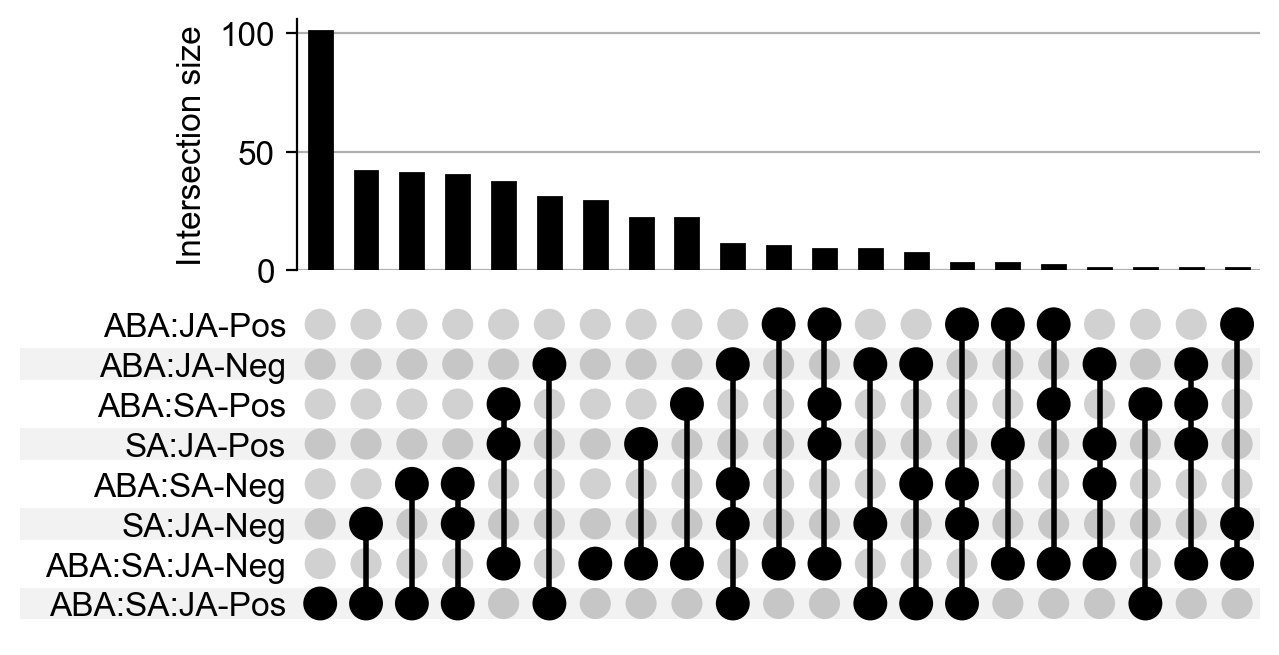

In [ ]:
fig = plt.figure(figsize=(8,3))
ax = upsetplot.plot(df_us, min_degree=1,  sort_by='cardinality', show_counts=False, fig=fig)['totals']
fig.delaxes(ax)
fig.set_size_inches(8, 4) 

In [ ]:
df_interDeg3 = df_interDeg.query("time == '3 hpt'")
df_degBulkSign3 = df_interDeg3.assign(
    Time_Hormone=lambda _: _.contrast.astype(str) + '-' + _.Direction.astype(str)
)
df_us = upsetplot.from_contents(df_degBulkSign3.groupby('Time_Hormone')['gene'].apply(set).to_dict())
_ls = df_interDeg3.query("contrast == 'ABA:SA:JA'")['gene']
df_us = df_us.query('id in @_ls')

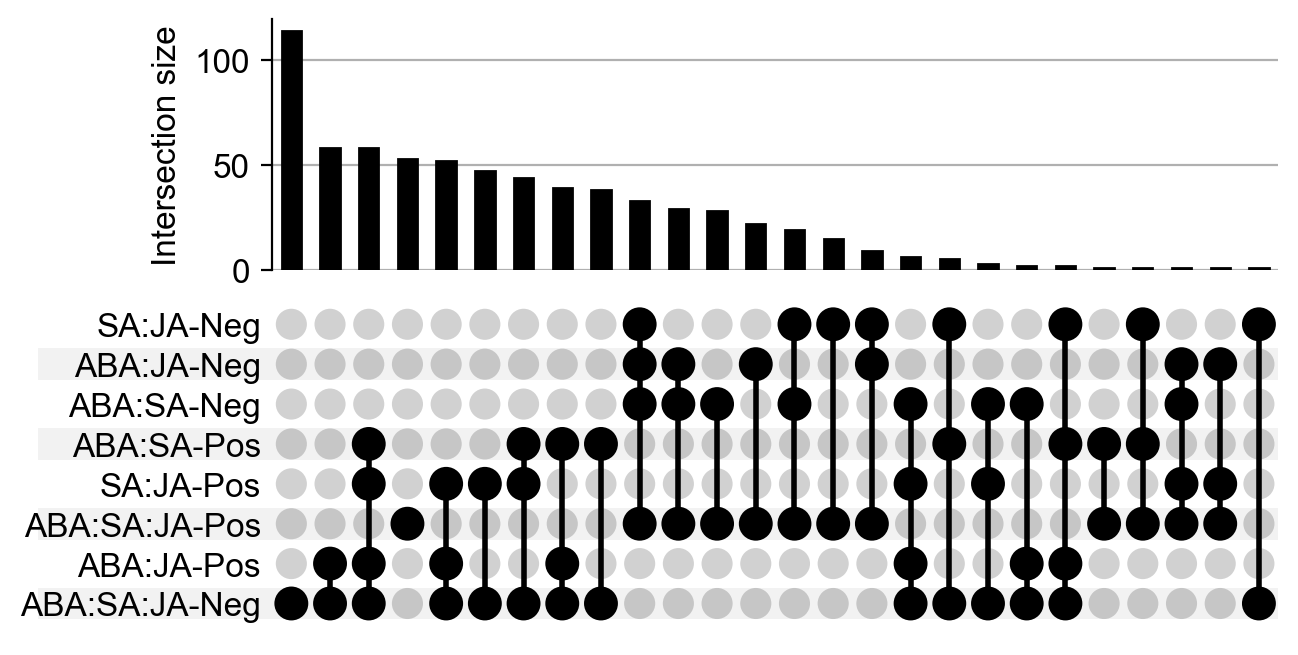

In [ ]:
fig = plt.figure(figsize=(8,3))
ax = upsetplot.plot(df_us, min_degree=1,  sort_by='cardinality', show_counts=False, fig=fig)['totals']
fig.delaxes(ax)
fig.set_size_inches(8, 4) 

In [ ]:
_ls = ['ABA_JA_Interaction', 'ABA_SA_Interaction', 'ABA_SA_JA_Interaction', 'SA_JA_Interaction']

In [ ]:
df_interDeg.query("logFC.abs() > 1 and FDR < 0.05 and contrast in @_ls").assign(
    Direction=lambda _: _.Direction.map({'Up':'Pos', 'Down':'Neg'})
).to_excel("/datapool/data/Users/zhijian/projects/hormone/0510_tem/bulk.int.xlsx")

# GO

## two way interact

In [ ]:
df_interDegTwoWay = df_interDeg.query("FDR < 0.05 & logFC.abs() > 1 & contrast.str.contains('Interaction') & contrast != 'ABA_SA_JA_Interaction'")

In [ ]:
_ls =[] 
for time in df_interDegTwoWay['time'].unique():
    for contrast in df_interDegTwoWay['contrast'].unique():
        for direction in ['Up', 'Down']:
            _df = df_interDegTwoWay.query(
                "time == @time & contrast == @contrast & Direction == @direction", engine='python'
            )
            if _df.empty:
                continue
            ls_gene = list(_df['gene'])
            _df = enrichrUsingGsea(
                ls_gene,
                dt_goForGseapy,
                cutoff=1,
                background=ead.var.index.tolist(),
            )
            _ls.append(
                _df.assign(contrast=contrast, Direction=direction, time=time)
            )

In [ ]:
df_goRes = pd.concat(_ls, ignore_index=True)

In [ ]:
def _fc(x):
    for i, y in zip(range(3), ['salicylic', 'jasmonic', 'abscisic',]):
        if y in x.lower():
            return i+1
    return False
df_goRes = df_goRes.assign(
    hormone_related=lambda d: d['Term'].apply(_fc)
).query("hormone_related != False")

In [ ]:
_df = df_goRes.query("`Adjusted P-value` < 0.01 & geneIn > 2")
_df = _df.sort_values('P-value',).drop_duplicates(['Term', 'time', 'contrast']).sort_values("hormone_related")
_df['hormone_related'] = _df['hormone_related'].map(
    {1:'SA-related', 2:'JA-related', 3:'ABA-related'}
)
_df['Direction'] = _df['Direction'].map({'Up':'Positive Interaction', 'Down': 'Negative Interaction'})

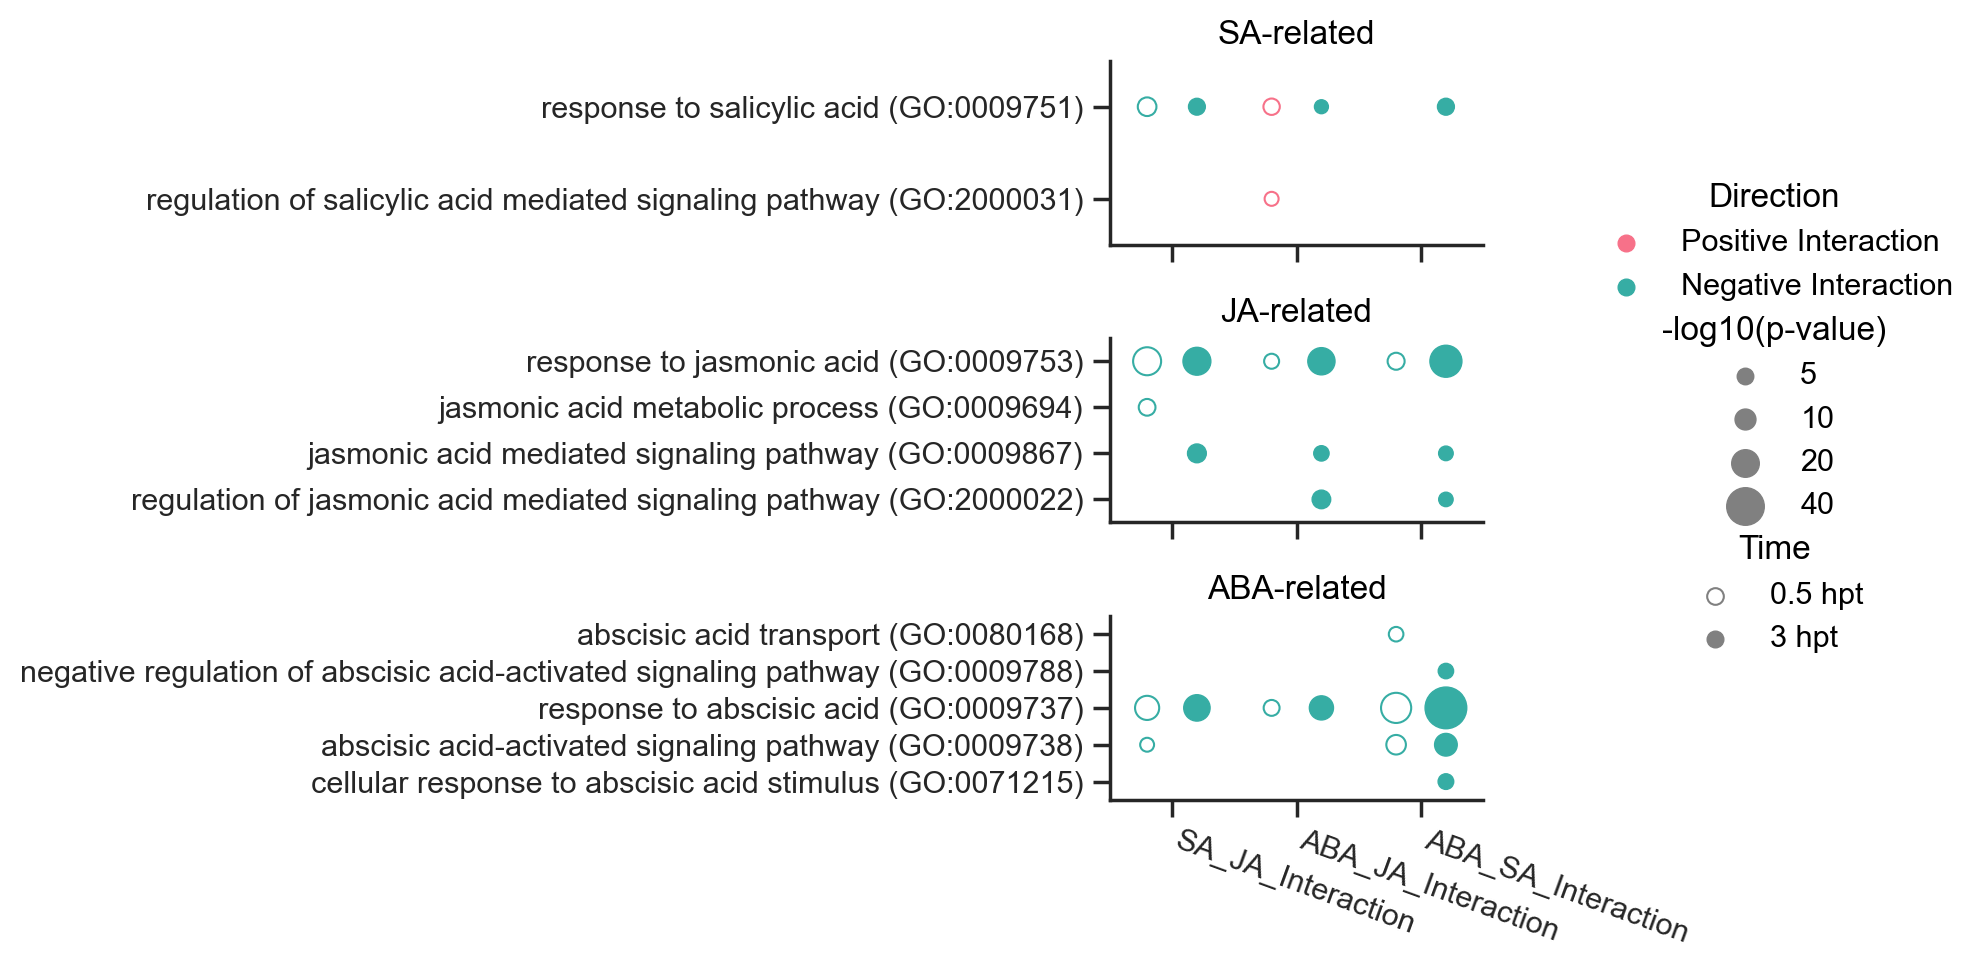

In [ ]:
fig = (
    so.Plot(
        data=_df,
        x="contrast",
        y="Term",
        color="Direction",
        pointsize="-log10(p)",
        fill="time",
    )
    .facet(row='hormone_related')
    .add(so.Dot(), so.Dodge(by=["fill"]))
    .share(y=False,)
    .layout(size=(8,5))
    .scale(
        color=so.Nominal(order=["Positive Interaction", "Negative Interaction"]),
        pointsize=so.Continuous(values=(5, 15)).tick(at=(0, 5, 10, 20, 40)),
        fill=so.Nominal([False, True], order=['0.5 hpt', '3 hpt'])
    )
    .label(x='',y='', color='Direction', pointsize='-log10(p-value)', fill='Time')
).plot()._figure
ax = fig.axes[-1]
ax.set_xticklabels(ax.get_xticklabels(), rotation=-20, ha='left')
fig

# 3 way

In [ ]:
df_interDegTwoWay = df_interDeg.query("FDR < 0.05 & logFC.abs() > 1 & contrast.str.contains('Interaction') & contrast != 'ABA_SA_JA_Interaction'")

In [ ]:
df_interDegThreeWay = df_interDeg.query("FDR < 0.05 & logFC.abs() > 1 & contrast == 'ABA_SA_JA_Interaction'")

In [ ]:
_ls =[] 
for time in df_interDegTwoWay['time'].unique():
    df_base = df_interDegTwoWay.query(
                "time == @time", engine='python'
            )
    ls_base = df_base['gene'].tolist()
    for contrast in df_interDegThreeWay['contrast'].unique():
        for direction in ['Up', 'Down']:
            _df = df_interDegThreeWay.query(
                "time == @time & contrast == @contrast & Direction == @direction & gene not in @ls_base", engine='python'
            )
            if _df.empty:
                continue
            ls_gene = list(_df['gene'])
            _df = enrichrUsingGsea(
                ls_gene,
                dt_goForGseapy,
                cutoff=1,
                background=ead.var.index.tolist(),
            )
            _ls.append(
                _df.assign(contrast=contrast, Direction=direction, time=time)
            )

In [ ]:
df_goRes = pd.concat(_ls, ignore_index=True)

In [ ]:
def _fc(x):
    for i, y in zip(range(3), ['salicylic', 'jasmonic', 'abscisic',]):
        if y in x.lower():
            return i+1
    return False
df_goRes = df_goRes.assign(
    hormone_related=lambda d: d['Term'].apply(_fc)
)

In [ ]:
df_goRes['Direction'] = df_goRes['Direction'].map({'Up':'Positive Interaction', 'Down': 'Negative Interaction'})

In [ ]:
_df = df_goRes.query("`Adjusted P-value` < 0.01 & geneIn > 2").sort_values('P-value',).drop_duplicates(['Term', 'time', 'contrast'])


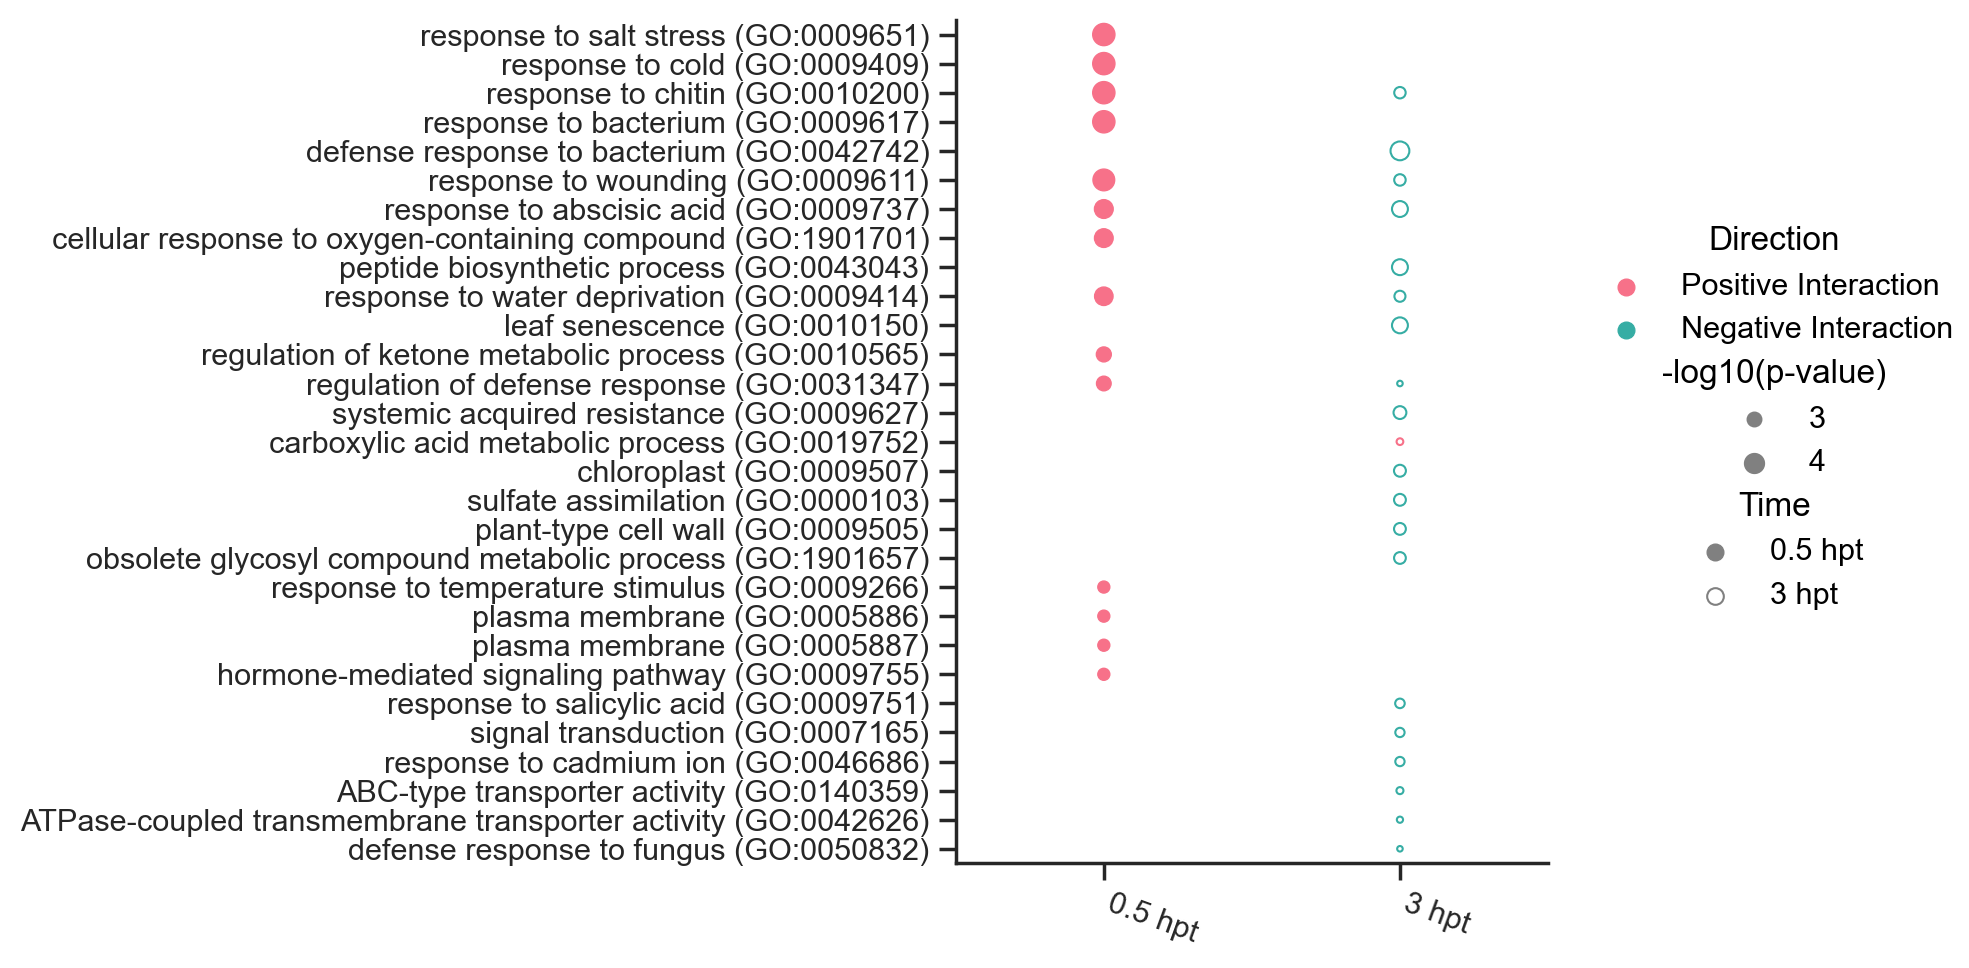

In [ ]:
fig = (
    so.Plot(
        data=_df,
        x="time",
        y="Term",
        color="Direction",
        pointsize="-log10(p)",
        fill="time",
    )
    .add(so.Dot(),)
    .label(x='',y='', color='Direction', pointsize='-log10(p-value)', fill='Time')
    .layout(size=(8, 5))
).plot()._figure
ax = fig.axes[-1]
ax.set_xticklabels(ax.get_xticklabels(), rotation=-20, ha='left')
fig